In [1]:

# Importing required libraries 
import numpy as np 
import pandas as pd 
import matplotlib as plt 
from statsmodels.tsa.seasonal import seasonal_decompose 
  
# Read the AirPassengers dataset 
sea_passanger = pd.read_csv('2020-2025.csv',
                            index_col ='Tahun', 
                            parse_dates = True) 
  


C:\Users\athiy\AppData\Local\Temp\ipykernel_35124\75316304.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sea_passanger = pd.read_csv('2020-2025.csv',


In [2]:
# Print the first five rows of the dataset 
sea_passanger
  

,Penumpang
Tahun,
2020-01-01,18821
2020-02-01,14667
2020-03-01,17103
2020-04-01,5024
2020-05-01,2267
...,...
2024-11-01,23251
2024-12-01,25349
2025-01-01,18614


In [3]:
sea_passanger.describe()

,Penumpang
count,63.000000
mean,22934.492063
std,12850.799544
min,2267.000000
25%,13731.000000
50%,19754.000000
75%,32522.000000
max,61649.000000


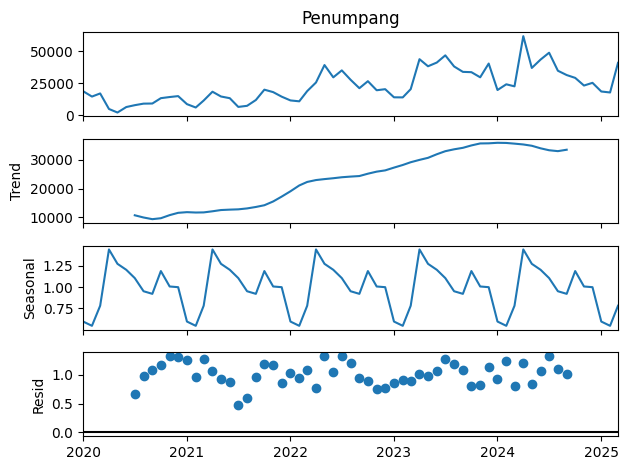

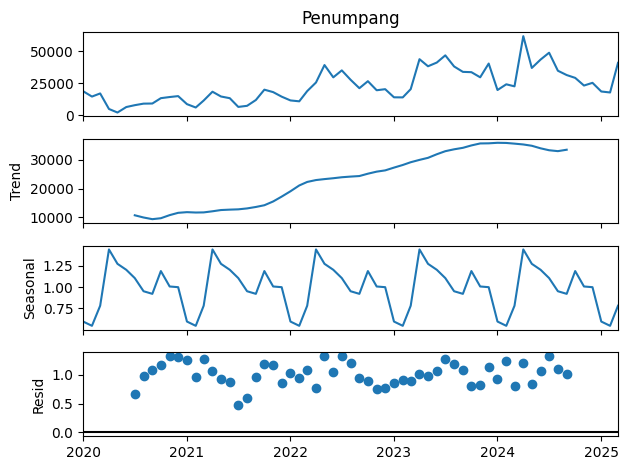

In [4]:
# ETS Decomposition 
result = seasonal_decompose(sea_passanger['Penumpang'],  
                            model ='multiplicative') 
  
# ETS plot  
result.plot() 


In [5]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(sea_passanger['Penumpang'])

ADF Statistic: -0.6640931527930876
p-value: 0.8558323273693839
Non-Stationary


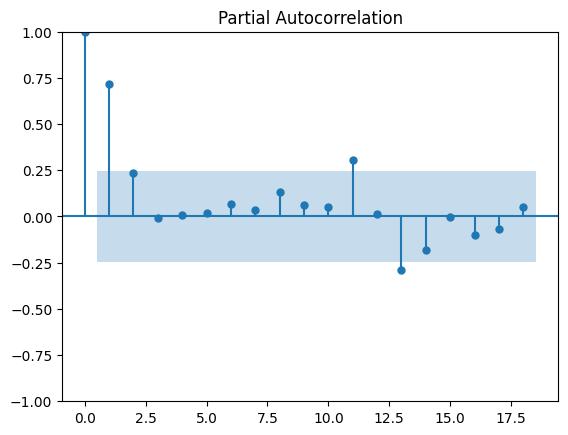

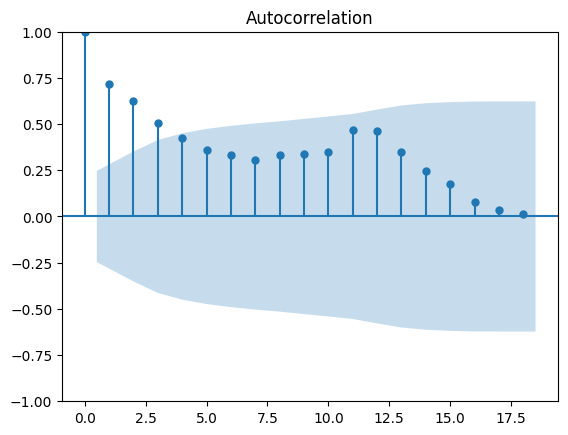

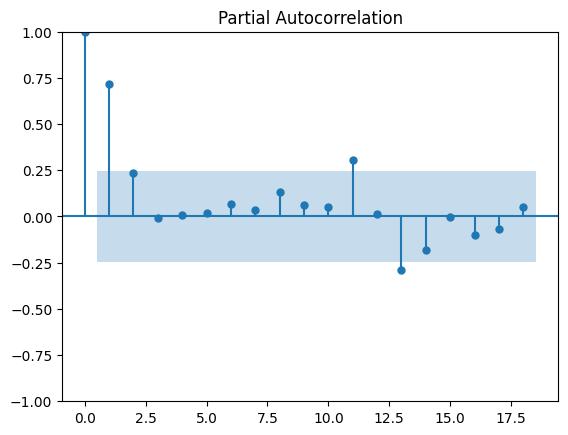

In [6]:
plot_acf(sea_passanger['Penumpang'])

plot_pacf(sea_passanger['Penumpang'])

In [7]:
# Import the library 
from pmdarima import auto_arima 

# Ignore harmless warnings 
import warnings 
warnings.filterwarnings("ignore") 

# Fit auto_arima function to AirPassengers dataset 
stepwise_fit = auto_arima(sea_passanger['Penumpang'], start_p = 1, start_q = 1, 
						max_p = 3, max_q = 3, m = 12, 
						start_P = 0, seasonal = True, 
						d = None, D = 1, trace = True, 
						error_action ='ignore', # we don't want to know if an order does not work 
						suppress_warnings = True, # we don't want convergence warnings 
						stepwise = True)		 # set to stepwise 

# To print the summary 
stepwise_fit.summary() 


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=1069.692, Time=0.31 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=1077.009, Time=0.04 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=1069.029, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=1071.455, Time=0.16 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=1091.156, Time=0.04 sec
 ARIMA(1,0,0)(0,1,0)[12] intercept   : AIC=1069.607, Time=0.06 sec
 ARIMA(1,0,0)(2,1,0)[12] intercept   : AIC=1070.697, Time=0.71 sec
 ARIMA(1,0,0)(1,1,1)[12] intercept   : AIC=1069.970, Time=0.34 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=1068.027, Time=0.16 sec
 ARIMA(1,0,0)(0,1,2)[12] intercept   : AIC=1070.026, Time=0.75 sec
 ARIMA(1,0,0)(1,1,2)[12] intercept   : AIC=1071.930, Time=1.14 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=1075.935, Time=0.13 sec
 ARIMA(2,0,0)(0,1,1)[12] intercept   : AIC=1068.474, Time=0.21 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=1069.232, Time=0.53 sec
 ARIMA(1,0,0)(0,1,1

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                   63
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -530.013
Date:                              Tue, 03 Feb 2026   AIC                           1068.027
Time:                                      14:33:44   BIC                           1075.754
Sample:                                  01-01-2020   HQIC                          1070.980
                                       - 03-01-2025                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3334.5091   1158.140      2.879      0.004    1064.597    5604.421
ar.L1          0.4298      0.121      3.543      0.000       0.192       0.667
ma.S.L12      -0.3007      0.134     -2.246      0.025      -0.563      -0.038
sigma2      5.981e+07      0.067   8.97e+08      0.000    5.98e+07    5.98e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.21   Jarque-Bera (JB):                 2.82
Prob(Q):                              0.65   Prob(JB):                         0.24
Heteroskedasticity (H):               1.52   Skew:                             0.57
Prob(H) (two-sided):                  0.40   Kurtosis:                         3.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.84e+25. Standard errors may be unstable.
"""

In [8]:
# Split data into train / test sets 
train = sea_passanger.iloc[:len(sea_passanger)-12] 
test = sea_passanger.iloc[len(sea_passanger)-12:] # set one year(12 months) for testing 

# Fit ARIMA(1, 0, 0)x(0, 1, 0, 12) on the training set 
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Penumpang'], 
				order = (1, 0, 0), 
				seasonal_order =(0, 1, 1, 12)) 

result = model.fit() 
result.summary() 


<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                          Penumpang   No. Observations:                   51
Model:             ARIMA(1, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -405.382
Date:                            Tue, 03 Feb 2026   AIC                            816.764
Time:                                    14:33:45   BIC                            821.754
Sample:                                01-01-2020   HQIC                           818.554
                                     - 03-01-2024                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7529      0.100      7.512      0.000       0.556       0.949
ma.S.L12      -0.2960      0.171     -1.733      0.083      -0.631       0.039
sigma2      5.709e+07   5.49e-10   1.04e+17      0.000    5.71e+07    5.71e+07
===================================================================================
Ljung-Box (L1) (Q):                   1.75   Jarque-Bera (JB):                 0.96
Prob(Q):                              0.19   Prob(JB):                         0.62
Heteroskedasticity (H):               1.48   Skew:                             0.22
Prob(H) (two-sided):                  0.49   Kurtosis:                         3.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.21e+33. Standard errors may be unstable.
"""

<Axes: xlabel='Tahun'>

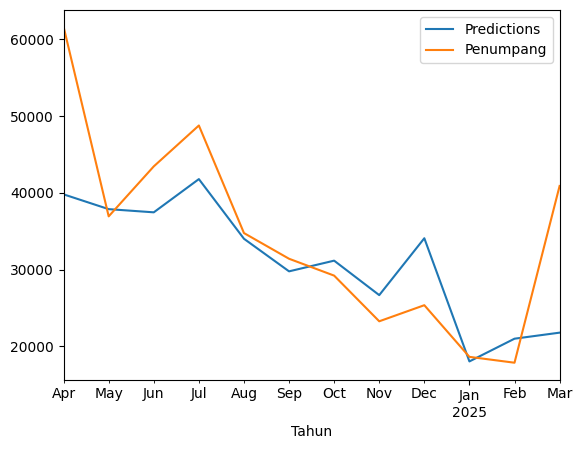

In [9]:
start = len(train) 
end = len(train) + len(test) - 1

# Predictions for one-year against the test set 
predictions = result.predict(start, end, 
							typ = 'levels').rename("Predictions") 

# plot predictions and actual values 
predictions.plot(legend = True) 
test['Penumpang'].plot(legend = True) 


In [10]:
# Load specific evaluation tools 
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tools.eval_measures import rmse 

# Calculate root mean squared error 
RMSE = rmse(test["Penumpang"], predictions) 

# Calculate mean squared error 
MSE = mean_squared_error(test["Penumpang"], predictions) 

# Calculate mean absolute error 
MAE = mean_absolute_error(test["Penumpang"], predictions) 

# R squared
R2 = r2_score(test["Penumpang"], predictions) 

# MAPE
MAPE = mean_absolute_percentage_error(test['Penumpang'], predictions)


In [11]:
print(f'''
RMSE   : { round(RMSE, 3) }

MSE   : { round(MSE, 3) }

MAE   : { round(MAE, 3) }

R2    : { round(R2, 3) }

MAPE   : { round(MAPE, 3) }
MAPE % : { round(MAPE*100, 3) } %
''')



RMSE   : 9281.063

MSE   : 86138135.631

MAE   : 6257.513

R2    : 0.44

MAPE   : 0.164
MAPE % : 16.396 %



In [12]:
mae_percentage = (MAE / np.mean(test['Penumpang'])) * 100
print("Mean absolute error on test set: {:.2f}%".format(mae_percentage))

Mean absolute error on test set: 18.22%


<Axes: xlabel='Tahun'>

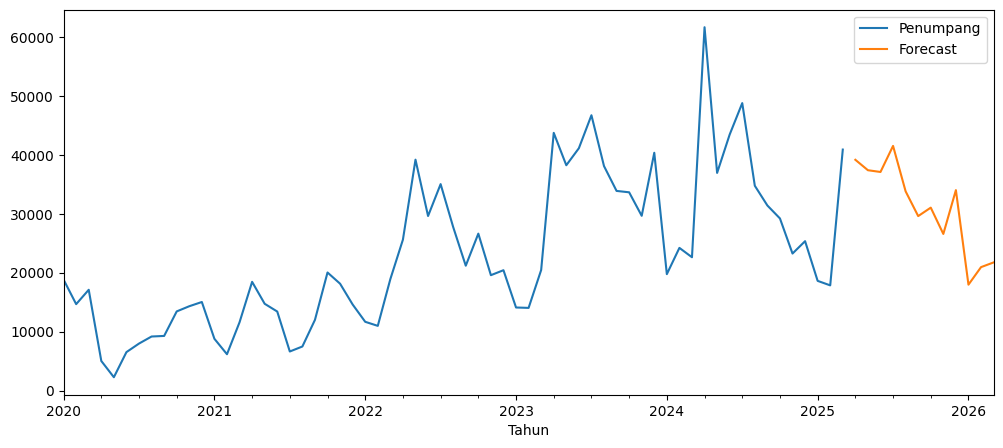

In [13]:
# Train the model on the full dataset 
# Forecast for the next year
forecast = result.predict(start = len(sea_passanger), 
						end = (len(sea_passanger)-1) + 1 * 12, 
						typ = 'levels').rename('Forecast') 

# Plot the forecast values 
sea_passanger['Penumpang'].plot(figsize = (12, 5), legend = True) 
forecast.plot(legend = True) 


In [14]:
print(forecast)


2025-04-01    39156.836182
2025-05-01    37386.801643
2025-06-01    37090.638036
2025-07-01    41512.325309
2025-08-01    33803.409964
2025-09-01    29606.304748
2025-10-01    31038.801984
2025-11-01    26574.824306
2025-12-01    34011.266892
2026-01-01    17969.768032
2026-02-01    20945.313071
2026-03-01    21742.504652
Freq: MS, Name: Forecast, dtype: float64
